# Treino local com Llama + Unsloth no Google Colab

Este notebook treina um adapter LoRA/QLoRA para o fluxo de detecção de violência doméstica usando `data/`.

Antes de rodar: em `Runtime > Change runtime type`, selecione GPU. Uma T4 costuma funcionar para o modelo 8B em 4 bits, com batch pequeno.


## 1. Instalar dependências

A instalação pode levar alguns minutos e talvez o Colab peça para reiniciar o runtime. Se reiniciar, rode as células novamente a partir daqui.


In [1]:
%%capture
!pip install -U unsloth
!pip install -U --no-deps trl peft accelerate bitsandbytes datasets transformers


## 2. Conferir GPU


In [2]:
!nvidia-smi


Mon May 25 12:52:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Montar Google Drive e definir caminhos

O notebook usa o Drive por padrão para ler o dataset e salvar o adapter/tokenizer treinado.

Caminho esperado no Drive:

```text
MyDrive/techchallenge3/data/violence_detection_finetuning.jsonl
```

Se você fizer upload manual no Colab como `/content/violence_detection_finetuning.jsonl`, a célula abaixo copia esse arquivo para o Drive automaticamente.


In [3]:
from pathlib import Path
from google.colab import drive
import shutil

drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
PROJECT_DIR = Path('/content/drive/MyDrive/techchallenge3')
DATA_DIR = PROJECT_DIR / 'data'
OUTPUT_DIR = PROJECT_DIR / 'outputs' / 'llama-womens-health-triage-lora'

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)

DATASET_FILES = [
    "planejamento_familiar.jsonl",
    "protocolos_atendimento_gine_obs.jsonl",
    "protocolos_triagem_cancer.jsonl",
    "casos_triagem_obstetricia.jsonl",
    "triagem_saude_mulher_dataset.jsonl",
    "violence_detection_finetuning.jsonl"
]

for filename in DATASET_FILES:
    dest_path = DATA_DIR / filename
    local_upload_path = Path('/content') / filename

    if not dest_path.exists() and local_upload_path.exists():
        shutil.copy2(local_upload_path, dest_path)
        print(f'Dataset copiado para o Drive: {dest_path}')

for filename in DATASET_FILES:
    assert (DATA_DIR / filename).exists(), f'Dataset {filename} não encontrado no Drive ou em /content.'

print('Todos os caminhos validados com sucesso!')
print('Saída do modelo:', OUTPUT_DIR)


Todos os caminhos validados com sucesso!
Saída do modelo: /content/drive/MyDrive/techchallenge3/outputs/llama-womens-health-triage-lora


## 4. Carregar e validar o JSONL


In [5]:
import json
from statistics import mean

def load_chat_jsonl(path):
    examples = []
    with open(path, encoding='utf-8') as file:
        for line_number, line in enumerate(file, start=1):
            if not line.strip():
                continue
            payload = json.loads(line)
            messages = payload.get('messages')
            if not isinstance(messages, list) or len(messages) < 3:
                raise ValueError(f'Linha {line_number} sem messages válidas')
            for message in messages:
                if message.get('role') not in {'system', 'user', 'assistant'}:
                    raise ValueError(f'Linha {line_number} com role inválido: {message}')
                if not message.get('content'):
                    raise ValueError(f'Linha {line_number} com content vazio: {message}')
            examples.append(payload)
    if not examples:
        raise ValueError('Dataset vazio')
    return examples




In [7]:
examples = []

for filename in DATASET_FILES:
    file_path = DATA_DIR / filename
    try:
        file_examples = load_chat_jsonl(file_path)
        examples.extend(file_examples)
        print(f'Sucesso: {len(file_examples)} exemplos carregados de {filename}')
    except Exception as e:
        print(f'Erro ao carregar {filename}: {e}')

print(f'\n--> Total de exemplos combinados para o treinamento: {len(examples)}')

Sucesso: 50 exemplos carregados de planejamento_familiar.jsonl
Sucesso: 55 exemplos carregados de protocolos_atendimento_gine_obs.jsonl
Sucesso: 39 exemplos carregados de protocolos_triagem_cancer.jsonl
Sucesso: 36 exemplos carregados de casos_triagem_obstetricia.jsonl
Sucesso: 30 exemplos carregados de triagem_saude_mulher_dataset.jsonl
Sucesso: 60 exemplos carregados de violence_detection_finetuning.jsonl

--> Total de exemplos combinados para o treinamento: 270


In [8]:
len(examples), examples[0]['messages'][1]

(270,
 {'role': 'user',
  'content': 'Mulher de 36 anos, tabagista (15 cigarros/dia), hipertensa controlada com medicação, solicita início de método contraceptivo na consulta de planejamento familiar. Qual a conduta e quais métodos são contraindicados?'})

## 5. Carregar Llama com Unsloth

O modelo abaixo é carregado em 4 bits para reduzir VRAM. Você pode trocar por outro modelo compatível do Unsloth.


In [9]:
from unsloth import FastLanguageModel

MODEL_NAME = 'unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit'
MAX_SEQ_LENGTH = 2048
LOAD_IN_4BIT = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.7: Fast Llama patching. Transformers: 5.9.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

[transformers] Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.


## 6. Formatar com chat template e tokenizar preview

Aqui o dataset passa pelo tokenizer. O objetivo é medir tamanho em tokens e verificar se haverá truncamento.


In [10]:
def render_messages(messages, tokenizer):
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

def format_dataset_into_model_input(examples, tokenizer):
    return [
        {
            'text': render_messages(example['messages'], tokenizer),
            'metadata': example.get('metadata', {}),
        }
        for example in examples
    ]




In [11]:
formatted_examples = format_dataset_into_model_input(examples, tokenizer)

token_lengths = []
truncated = 0
for example in formatted_examples:
    tokens = tokenizer(
        example['text'],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        add_special_tokens=False,
    )
    length = len(tokens['input_ids'])
    token_lengths.append(length)
    if length >= MAX_SEQ_LENGTH:
        truncated += 1

{
    'examples': len(formatted_examples),
    'min_tokens': min(token_lengths),
    'avg_tokens': round(mean(token_lengths), 2),
    'max_tokens': max(token_lengths),
    'truncated_examples': truncated,
}

{'examples': 270,
 'min_tokens': 226,
 'avg_tokens': 384.44,
 'max_tokens': 654,
 'truncated_examples': 0}

In [12]:
formatted_examples

[{'text': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\nVocê é um assistente virtual especializado em planejamento familiar e saúde reprodutiva de nível ambulatorial e hospitalar. Sua função é aplicar estritamente os Critérios Médicos de Elegibilidade da OMS para orientar a escolha contraceptiva de forma segura.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nMulher de 36 anos, tabagista (15 cigarros/dia), hipertensa controlada com medicação, solicita início de método contraceptivo na consulta de planejamento familiar. Qual a conduta e quais métodos são contraindicados?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nAnálise de Elegibilidade (Critérios da OMS):\n- Paciente com > 35 anos e tabagista ativa ($\\ge$ 15 cigarros/dia) associado à Hipertensão Arterial: Classificação OMS 4 (Risco inaceitável à saúde) para Contraceptivos Hormonais Combinados.\n\nProtocolo de Conduta e Opções Recom

## 7. Preparar LoRA


In [13]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj',
    ],
    lora_alpha=16,
    lora_dropout=0.0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)


[transformers] Unsloth 2026.5.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


## 8. Treinar

Para demonstração, `max_steps=60`. Para um treino mais completo, aumente esse valor e monitore perda/overfitting.

A saída do treinamento também usa `OUTPUT_DIR`, que já aponta para o Google Drive.


In [14]:
from datasets import Dataset
from trl import SFTConfig, SFTTrainer
import inspect

train_dataset = Dataset.from_list(formatted_examples)

sft_params = inspect.signature(SFTConfig.__init__).parameters
sft_kwargs = {
    'output_dir': str(OUTPUT_DIR),
    'per_device_train_batch_size': 2,
    'gradient_accumulation_steps': 4,
    'warmup_steps': 5,
    'max_steps': 60,
    'learning_rate': 2e-4,
    'fp16': True,
    'logging_steps': 1,
    'optim': 'adamw_8bit',
    'weight_decay': 0.01,
    'lr_scheduler_type': 'linear',
    'seed': 3407,
    'report_to': 'none',
    'dataset_text_field': 'text',
    'packing': False,
    'padding_free': False,
}

if 'max_length' in sft_params:
    sft_kwargs['max_length'] = MAX_SEQ_LENGTH
elif 'max_seq_length' in sft_params:
    sft_kwargs['max_seq_length'] = MAX_SEQ_LENGTH

sft_kwargs = {key: value for key, value in sft_kwargs.items() if key in sft_params}
sft_config = SFTConfig(**sft_kwargs)

trainer_params = inspect.signature(SFTTrainer.__init__).parameters
trainer_kwargs = {
    'model': model,
    'train_dataset': train_dataset,
    'args': sft_config,
}

if 'processing_class' in trainer_params:
    trainer_kwargs['processing_class'] = tokenizer
elif 'tokenizer' in trainer_params:
    trainer_kwargs['tokenizer'] = tokenizer

trainer = SFTTrainer(**trainer_kwargs)
trainer.train()


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/270 [00:00<?, ? examples/s]

[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 270 | Num Epochs = 2 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,2.448112
2,2.518688
3,2.318406
4,2.262936
5,2.220505
6,2.073555
7,1.966570
8,1.820685
9,1.825627
10,1.721370


[transformers] Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/techchallenge3/outputs/llama-womens-health-triage-lora/checkpoint-60/tokenizer_config.json.


TrainOutput(global_step=60, training_loss=1.2167321582635244, metrics={'train_runtime': 682.932, 'train_samples_per_second': 0.703, 'train_steps_per_second': 0.088, 'total_flos': 9556870270943232.0, 'train_loss': 1.2167321582635244})

## 9. Salvar adapter e tokenizer no Google Drive

Esta célula salva explicitamente o adapter LoRA e o tokenizer em `MyDrive/techchallenge3/outputs/llama-violence-detection-lora`.


In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

saved_files = sorted(path.name for path in OUTPUT_DIR.iterdir())
print('Modelo/tokenizer salvos em:', OUTPUT_DIR)
saved_files


[transformers] Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/techchallenge3/outputs/llama-womens-health-triage-lora/tokenizer_config.json.


Modelo/tokenizer salvos em: /content/drive/MyDrive/techchallenge3/outputs/llama-womens-health-triage-lora


['README.md',
 'adapter_config.json',
 'adapter_model.safetensors',
 'chat_template.jinja',
 'checkpoint-60',
 'tokenizer.json',
 'tokenizer_config.json']

## 10. Testar inferência


In [16]:
FastLanguageModel.for_inference(model)

messages = [
    {
        'role': 'system',
        'content': 'Você é um assistente de apoio à triagem em saúde e segurança da mulher. Responda somente em JSON válido com classificação de risco, sinais de alerta, próxima etapa e resposta acolhedora.',
    },
    {
        'role': 'user',
        'content': 'Não aconteceu nada demais, somente um empurrão.',
    },
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors='pt',
).to('cuda')

outputs = model.generate(
    input_ids=inputs,
    max_new_tokens=512,
    temperature=0.2,
    do_sample=True,
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API und

system

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

Você é um assistente de apoio à triagem em saúde e segurança da mulher. Responda somente em JSON válido com classificação de risco, sinais de alerta, próxima etapa e resposta acolhedora.user

Não aconteceu nada demais, somente um empurrão.assistant

{"classificacao_risco": "moderado", "sinais_alerta": ["agressão física", "empurrão", "risco de escalada"], "proxima_etapa_fluxo": "encaminhamento_seguro", "resposta_acolhedora": "O empurrão pode parecer uma coisa menor, mas é importante lembrar que qualquer forma de violência física merece atenção e proteção. Vamos conversar em um lugar seguro e encontrar o melhor caminho para você."}


## 11. Compactar adapter para download opcional

Como o modelo já foi salvo no Drive, esta etapa é opcional. Ela cria um `.zip` no próprio Drive para facilitar download/backup.


In [17]:
ZIP_PATH = OUTPUT_DIR.parent / 'llama-violence-detection-lora.zip'
!cd {OUTPUT_DIR.parent} && zip -r {ZIP_PATH.name} {OUTPUT_DIR.name}
print('ZIP salvo em:', ZIP_PATH)


  adding: llama-womens-health-triage-lora/ (stored 0%)
  adding: llama-womens-health-triage-lora/README.md (deflated 46%)
  adding: llama-womens-health-triage-lora/checkpoint-60/ (stored 0%)
  adding: llama-womens-health-triage-lora/checkpoint-60/README.md (deflated 65%)
  adding: llama-womens-health-triage-lora/checkpoint-60/adapter_model.safetensors (deflated 7%)
  adding: llama-womens-health-triage-lora/checkpoint-60/adapter_config.json (deflated 58%)
  adding: llama-womens-health-triage-lora/checkpoint-60/chat_template.jinja (deflated 72%)
  adding: llama-womens-health-triage-lora/checkpoint-60/tokenizer_config.json (deflated 96%)
  adding: llama-womens-health-triage-lora/checkpoint-60/tokenizer.json (deflated 85%)
  adding: llama-womens-health-triage-lora/checkpoint-60/training_args.bin (deflated 53%)
  adding: llama-womens-health-triage-lora/checkpoint-60/optimizer.pt (deflated 11%)
  adding: llama-womens-health-triage-lora/checkpoint-60/scheduler.pt (deflated 62%)
  adding: llam

In [18]:
!pip install -q faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 24.0 MB/s eta 0:00:00


# 12. Criar base simples de protocolos



In [21]:
protocolos = {
    "violencia": "Em casos de violência doméstica, encaminhar para equipe especializada.",
    "sangramento": "Pacientes com sangramento intenso devem procurar emergência.",
    "gravidez": "Sintomas graves na gravidez exigem avaliação médica imediata.",
    "medicamento": "O assistente não pode prescrever medicamentos.",
    "diagnostico": "O assistente não pode fornecer diagnóstico definitivo.",
    "planejamento_familiar": "Informações sobre métodos contraceptivos devem ser fornecidas de forma neutra; encaminhar para consulta de planejamento familiar para escolha e prescrição.",
    "triagem_cancer": "Sinais de alerta como nódulos mamários ou sangramentos atípicos exigem encaminhamento prioritário para exames de rastreamento (mamografia/preventivo).",
    "trabalho_parto": "Identificar sinais de trabalho de parto (contrações regulares, perda de líquido) e orientar deslocamento imediato para a maternidade de referência.",
    "pre_natal": "Queixas de cefaleia forte, visão turva ou dor epigástrica na gestação são sinais de alerta para pré-eclâmpsia; encaminhar para avaliação urgente.",
    "sintomas_gerais_ginecologia": "Casos de corrimento com odor, dor pélvica crônica ou irregularidade menstrual severa devem ser agendados para consulta ginecológica de rotina.",
    "violencia_imediata": "Em caso de agressão física ou sexual recente (últimas 72h), direcionar imediatamente ao serviço de emergência/profilaxia e acolhimento social."
}

# 13. Criar RAG simples com FAISS

In [22]:
def buscar_contexto(pergunta):
    pergunta = pergunta.lower()
    contexto = []

    if any(p in pergunta for p in ["violência", "agressão", "abuso", "estupro", "violada"]):
        contexto.append(protocolos["violencia"])
        if any(p in pergunta for p in ["hoje", "ontem", "agora", "recente", "horas"]):
            contexto.append(protocolos["violencia_imediata"])

    if "sangramento" in pergunta or "sangrando" in pergunta or "hemorragia" in pergunta:
        contexto.append(protocolos["sangramento"])

    if any(p in pergunta for p in ["gravidez", "gestante", "grávida", "embrião", "feto"]):
        contexto.append(protocolos["gravidez"])
        if any(p in pergunta for p in ["dor de cabeça", "cefaleia", "visão turva", "vistas embaçadas", "pressão"]):
            contexto.append(protocolos["pre_natal"])
        if any(p in pergunta for p in ["contração", "contrações", "bolsa estourou", "líquido"]):
            contexto.append(protocolos["trabalho_parto"])

    if any(p in pergunta for p in ["anticoncepcional", "pílula", "diu", "camisinha", "evitar filhos", "engravidar", "preservativo"]):
        contexto.append(protocolos["planejamento_familiar"])

    if any(p in pergunta for p in ["nódulo", "caroço", "peito", "mama", "preventivo", "papanicolau", "câncer"]):
        contexto.append(protocolos["triagem_cancer"])

    if any(p in pergunta for p in ["corrimento", "coceira", "odor", "dor pélvica", "cólica", "menstruação", "atrasada"]):
        contexto.append(protocolos["sintomas_gerais_ginecologia"])

    contexto.append(protocolos["medicamento"])
    contexto.append(protocolos["diagnostico"])

    return "\n".join(contexto)

# 14. Criar prompt de segurança

In [24]:
SYSTEM_PROMPT = """
Você é um assistente de apoio à saúde da mulher.

REGRAS:
- Nunca prescreva medicamentos.
- Nunca forneça diagnóstico definitivo.
- Sempre sugira avaliação médica presencial em casos graves.
- Em casos suspeitos de violência doméstica, orientar encaminhamento especializado.
- Responda de forma ética e segura.
"""

# 15. Criar função simples de resposta

In [25]:
from transformers import TextStreamer


def responder(pergunta):

    docs = retriever.get_relevant_documents(pergunta)

    contexto = "\n".join([d.page_content for d in docs])

    prompt = f"""
    {SYSTEM_PROMPT}

    Contexto:
    {contexto}

    Pergunta:
    {pergunta}

    Resposta:
    """

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.3
    )

    resposta = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return resposta

# 16. Criar fluxo simples com LangGraph

In [26]:
from typing import TypedDict
from langgraph.graph import StateGraph, END


class Estado(TypedDict):
    pergunta: str
    risco: str
    resposta: str

# Nó de classificação

In [28]:
def classificar_risco(state):
    pergunta = state["pergunta"].lower()

    palavras_alto_risco = [
        "agressão", "violência", "abuso", "estupro", "violada", "agredida",
        "sangramento", "sangrando", "hemorragia",
        "dor intensa", "dor insuportável", "dor muito forte",
        "contração", "contrações", "bolsa estourou",
        "visão turva", "vistas embaçadas", "dor de cabeça forte", "cefaleia"
    ]

    palavras_medio_risco = [
        "nódulo", "caroço", "peito", "mama",
        "preventivo", "papanicolau", "atrasado",
        "corrimento", "coceira", "odor", "cheiro",
        "dor pélvica", "cólica forte", "menstruação"
    ]

    risco = "baixo"

    if any(p in pergunta for p in palavras_alto_risco):
        risco = "alto"
    elif any(p in pergunta for p in palavras_medio_risco):
        risco = "médio"

    return {
        "pergunta": state["pergunta"],
        "risco": risco
    }

# Nó de resposta

In [29]:
def gerar_resposta(state):

    resposta = responder(state["pergunta"])

    return {
        "pergunta": state["pergunta"],
        "risco": state["risco"],
        "resposta": resposta
    }

# Nó de emergência

In [30]:
def emergencia(state):

    return {
        "pergunta": state["pergunta"],
        "risco": state["risco"],
        "resposta": "CASO SENSÍVEL IDENTIFICADO. Encaminhar imediatamente para equipe médica especializada."
    }

# Fluxo do grafo

In [31]:
graph = StateGraph(Estado)

graph.add_node("classificar", classificar_risco)
graph.add_node("resposta", gerar_resposta)
graph.add_node("emergencia", emergencia)


graph.set_entry_point("classificar")


def decisao(state):
    if state["risco"] == "alto":
        return "emergencia"
    return "resposta"


graph.add_conditional_edges(
    "classificar",
    decisao,
    {
        "emergencia": "emergencia",
        "resposta": "resposta"
    }
)


graph.add_edge("resposta", END)
graph.add_edge("emergencia", END)

app = graph.compile()

# 17. Visualizar o grafo

> Esta célula renderiza o fluxo do LangGraph para apresentação, mostrando o ponto de decisão entre resposta padrão e encaminhamento de emergência.

Se a imagem não puder ser gerada no ambiente atual, o notebook exibe a definição Mermaid do grafo como fallback.

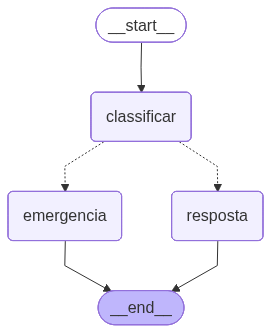

In [32]:
from IPython.display import Image, display

graph_view = app.get_graph()

try:
    png_data = graph_view.draw_mermaid_png()
    display(Image(data=png_data))
except Exception as error:
    print('Nao foi possivel renderizar o PNG do grafo neste ambiente.')
    print(f'Erro: {error}')
    print('\nDefinicao Mermaid do grafo:\n')
    print(graph_view.draw_mermaid())

In [34]:
resultado = app.invoke({
    "pergunta": "Estou sofrendo agressão do meu parceiro"
})

print(resultado)

{'pergunta': 'Estou sofrendo agressão do meu parceiro', 'risco': 'alto', 'resposta': 'CASO SENSÍVEL IDENTIFICADO. Encaminhar imediatamente para equipe médica especializada.'}


# 18. Adicionar logs

In [35]:
import pandas as pd
from datetime import datetime

logs = []


def salvar_log(pergunta, resposta, risco):

    logs.append({
        "timestamp": str(datetime.now()),
        "pergunta": pergunta,
        "risco": risco,
        "resposta": resposta
    })

    pd.DataFrame(logs).to_csv("logs.csv", index=False)

In [36]:
salvar_log(
    resultado["pergunta"],
    resultado["resposta"],
    resultado["risco"]
)